 # Diagramas de arquitectura de los modelos recurrentes



 Figuras de la arquitectura de los tres modelos entrenados en `rnn_training.ipynb`, para la memoria. De cada uno las dibuja `models/services/architecture_diagram.py`, el módulo que comparten todos los cuadernos de diagramas de `models`:



 - La vista `graph` que **visualkeras** saca del modelo ya entrenado, sin escribir la estructura a mano.



 Aquí son **tres tandas** y no una, como en el cuaderno denso, porque los tres modelos del cuaderno de entrenamiento sí son redes distintas: el recurrente simple, el bidireccional y el bidireccional con atención. Lo que comparten es la entrada —el espectro de Gaia leído como una secuencia de 201 pasos, normalizado con la mediana de su flujo absoluto— y una cabeza densa parecida a la del modelo denso.



 Las arquitecturas descritas son las de `rnn_training.ipynb`, así que hay que repasarla si cambia alguna de las redes.

In [12]:
import sys

from pathlib import Path

# 'services' cuelga de 'models', así que esa carpeta va a 'sys.path'. 'solution'
# se localiza subiendo desde el directorio de trabajo, sin suponer dónde arranca
# el kernel: su marca es 'pyproject.toml'.
DIRECTORIES = (Path.cwd(), *Path.cwd().parents)
CANDIDATES = (*DIRECTORIES, *(directory / "solution" for directory in DIRECTORIES))
SOLUTION_DIR = next(
    candidate for candidate in CANDIDATES if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))

from services.architecture_diagram import DIAGRAMS_DIR, draw_diagrams
from services.paths import model_paths

MODEL_PATHS = {
    "gru":             model_paths("gru", "rnn").model
  , "birnn":           model_paths("birnn", "rnn").model
  , "birnn-attention": model_paths("birnn-attention", "rnn").model
}

print("Carpeta de trabajo:", SOLUTION_DIR)
print("Figuras en:", DIAGRAMS_DIR)


Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution
Figuras en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams


 El `.keras` guarda la arquitectura junto con los pesos. Los resúmenes sirven para comprobar contra los modelos entrenados las formas y el número de unidades que se describen aquí. La vista de visualkeras de cada modelo sí sale del modelo cargado.



 `AttentionPooling` es la capa propia de `rnn_training.ipynb`, y el `.keras` guarda su nombre pero no su código, así que hay que volver a definirla para poder cargar el modelo con atención.

In [13]:
import tensorflow as tf
from tensorflow.keras import layers


class AttentionPooling(layers.Layer):
    def build(self, input_shape):
        self.attention_dense = layers.Dense(1)
        super().build(input_shape)

    def call(self, inputs):
        weights = tf.nn.softmax(self.attention_dense(inputs), axis=1)
        return tf.reduce_sum(inputs * weights, axis=1)


CUSTOM_OBJECTS = {"AttentionPooling": AttentionPooling}

models = {
    name: tf.keras.models.load_model(path, custom_objects=CUSTOM_OBJECTS)
    for name, path in MODEL_PATHS.items()
}

for name, model in models.items():
    print(f"===== {name} =====")
    model.summary()


===== gru =====


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_13 (GRU)                    │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,122,944 (38.62 MB)

 Trainable params: 3,374,314 (12.87 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 201, 256)       │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 201, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling_1             │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,942,787 (64.63 MB)

 Trainable params: 5,647,595 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,295,192 (43.09 MB)

 ## Modelo recurrente simple



 La arquitectura de la red es la siguiente:



 - La entrada es el espectro de Gaia visto como una **secuencia de 201 pasos con una variable por paso**: el flujo de ese punto. Es la diferencia con el modelo denso, que recibe los mismos 201 números como un vector suelto; aquí el orden de los puntos —la longitud de onda creciente— sí forma parte del dato.

 - La **capa GRU de 128 unidades** recorre los 201 puntos arrastrando un estado y devuelve solo el último, un resumen de 128 números del espectro entero. Los estados intermedios se descartan (`return_sequences=False`), así que todo lo que la red sepa del espectro tiene que caber en ese resumen.

 - La cabeza densa, dos capas ocultas con `LeakyReLU` y una salida lineal de 2666, expande ese resumen hasta el espectro de SDSS completo. Es más corta que la del modelo denso: dos capas ocultas en lugar de cuatro.



 La celda GRU hace en cada uno de esos 201 pasos lo siguiente: dos puertas, ambas con activación sigmoide, deciden cuánto del estado anterior se conserva y cuánto entra en el estado candidato. Es lo que le permite arrastrar información de un extremo del espectro al otro sin que el gradiente se desvanezca por el camino. Las puertas son las mismas en los tres modelos del cuaderno.



 En las figuras la GRU es una sola caja: el recorrido por los 201 pasos ocurre dentro de ella, y ninguna vista puede enseñar sus puertas. Lo que enseñan es el **estrechamiento** de la red, del espectro de entrada al resumen de 128 números, y el ensanchamiento posterior hasta los 2666 de la salida.

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/gru_graph-diagram.png


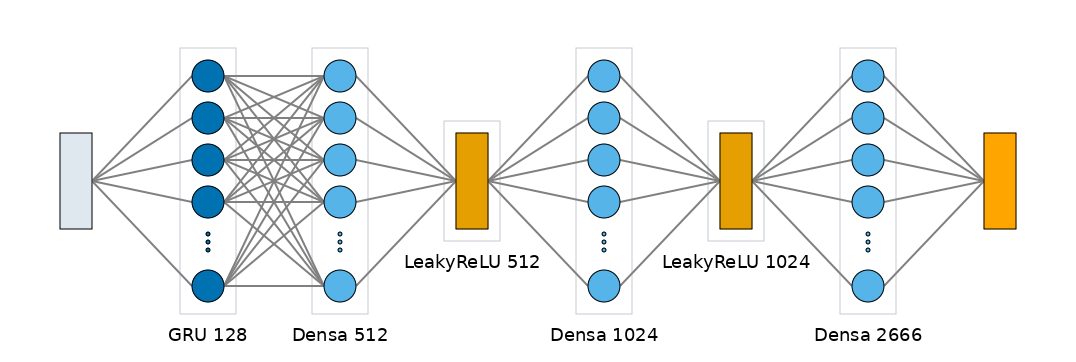

{'graph': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/gru_graph-diagram.png')}

In [14]:
draw_diagrams(models["gru"], "gru")


 ## Modelo bidireccional



 La arquitectura de la red es la siguiente:



 - La misma entrada, pero ahora la recorren **dos GRU de 128 unidades a la vez**, una en el sentido de la longitud de onda creciente y otra en sentido contrario. Cada una devuelve su último estado y los dos se concatenan en un resumen de 256 números.

 - Con una sola dirección, el resumen del espectro lo escribe una capa que al llegar al rojo lleva 201 pasos acumulados y solo uno al empezar por el azul. Con las dos, cada extremo del espectro está igual de cerca de una de las dos lecturas, y ninguna región queda al final de la memoria de las dos.

 - La cabeza densa es la del modelo denso, cuatro capas ocultas alternando `LeakyReLU` y `ELU`, y no la de dos del recurrente simple.



 Las dos lecturas del espectro son en el modelo una sola capa, `Bidirectional`, que envuelve a la GRU: en las figuras aparece como una única caja de 256 de salida, el doble de la GRU que envuelve.

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/birnn_graph-diagram.png


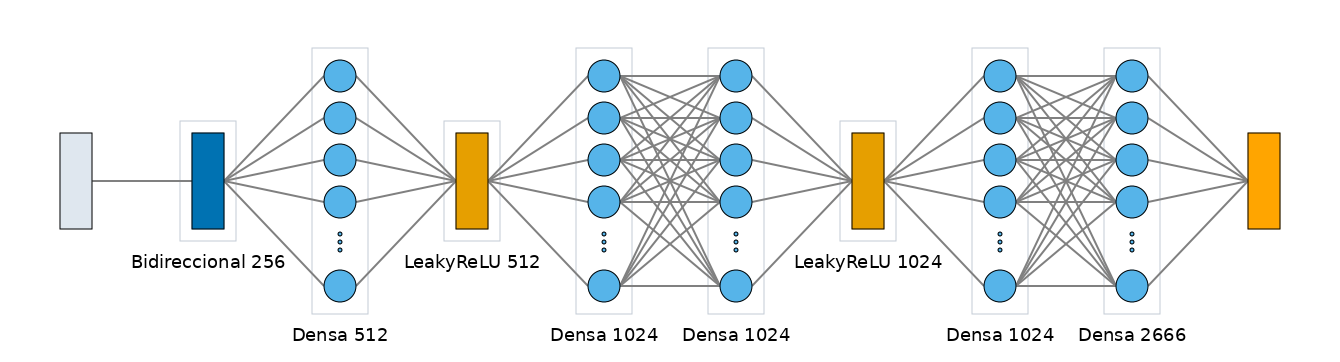

{'graph': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/birnn_graph-diagram.png')}

In [15]:
draw_diagrams(models["birnn"], "birnn")


 ## Modelo bidireccional con atención



 La arquitectura de la red es la siguiente:



 - Las capas recurrentes son ahora **dos, apiladas y las dos bidireccionales**, de 128 y de 64 unidades, y ninguna descarta los estados intermedios (`return_sequences=True`): la primera devuelve 201 estados de 256 números y la segunda otros 201 de 128, uno por punto del espectro.

 - El resumen del espectro ya no es el último estado sino una **media ponderada de los 201**, con unos pesos que la propia red aprende. Ahí está la diferencia con el modelo bidireccional: en lugar de obligar a que todo el espectro quepa en el estado con el que la capa recurrente termina de recorrerlo, la atención deja que cada espectro elija de qué puntos tira su resumen.

 - La cabeza densa es la misma que la del modelo bidireccional.



 La capa `AttentionPooling` son tres pasos: una capa densa de una sola neurona puntúa cada uno de los 201 estados, una `softmax` sobre los pasos convierte las puntuaciones en pesos que suman 1, y el resumen es la suma de los estados ponderada por ellos. La densa de la puntuación es todo lo que la capa añade en parámetros: 129 sobre los 5,65 millones de la red.



 Es el único de los tres modelos que Keras guarda como red funcional y no como pila de capas. En la vista `graph`, el pie de la `AttentionPooling` recoge lo que hace con la secuencia: recibe los 201 estados de 128 números de la segunda capa bidireccional y devuelve un único vector de 128, que es donde la secuencia se colapsa en el resumen.

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/birnn-attention_graph-diagram.png


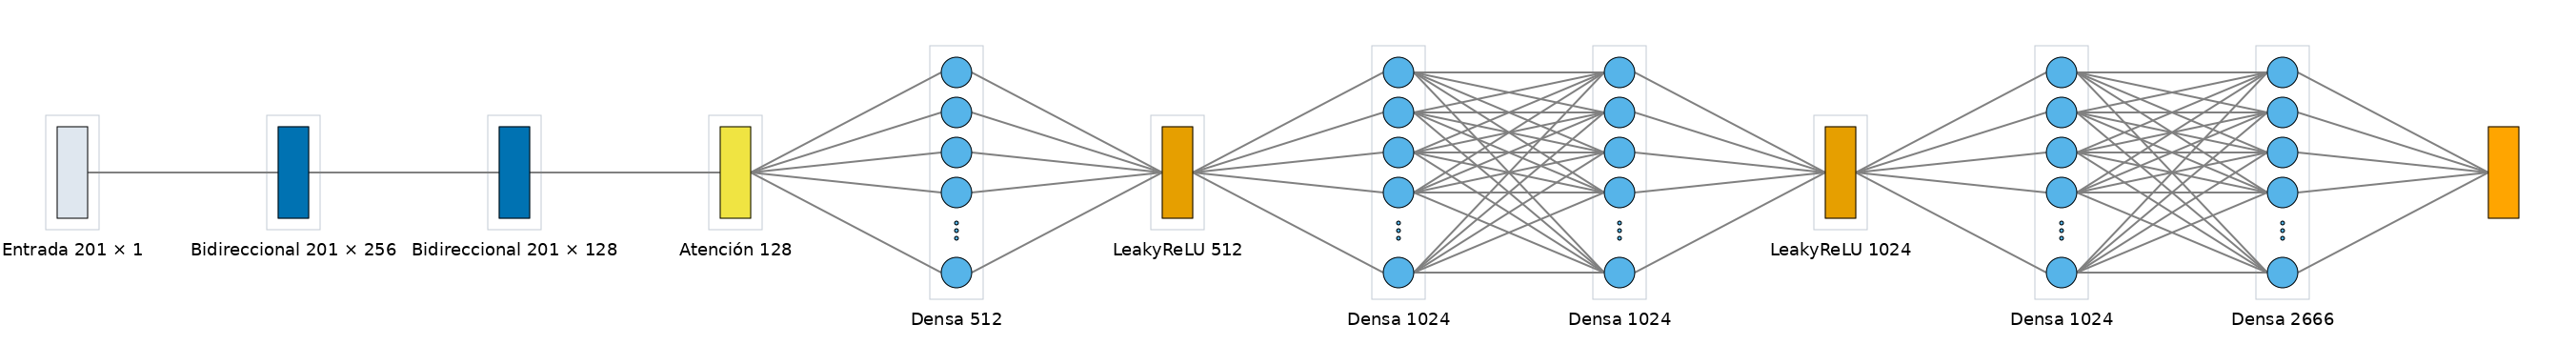

{'graph': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/birnn-attention_graph-diagram.png')}

In [16]:
# Los pies de las dos capas bidireccionales miden 288 píxeles, mucho más de lo
# que ocupa la columna que rotulan, así que esta figura separa sus columnas más
# que las comunes: con el hueco común, cada pie se solapa con el siguiente
draw_diagrams(
    models["birnn-attention"], "birnn-attention"
  , graph={"layer_spacing": 200}
)
